<a href="https://colab.research.google.com/github/isratrimii/Candle-Flame-Simulation/blob/main/Candle_Flame_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

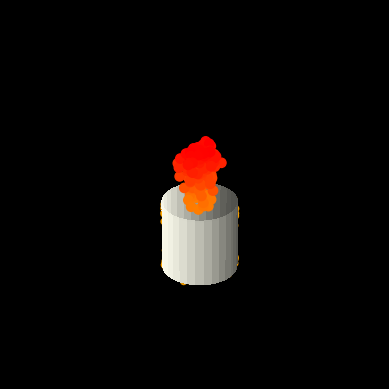

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from IPython.display import Video

# ------------------------------------------
# PARAMETERS
# ------------------------------------------
# Total flame particles = 250 (100 core + 150 outer)
num_flame = 250
num_core = 100    # For the bright center
num_outer = 150   # For the translucent outer glow
num_wax = 140
num_smoke = 120

candle_height = 3.0
candle_radius = 0.32
flame_height = 1.8 # Overall height of the outer flame

frames = 360
blowout_frame = 260

melt_rate = 0.0025
wax_fall_speed = 0.015
pool_depth = 0.10 # Max depth of the wax pool

# Global variable to track candle height
current_candle_height = candle_height

# ------------------------------------------
# INITIAL FLAME (stable teardrop shape for groups)
# ------------------------------------------
def init_flame_particle_group(num, width_factor):
    """Initializes particle positions in a teardrop/cone shape."""
    z = np.random.uniform(0, flame_height, num)
    # Teardrop/Cone Shape Formula: Widest at z=0, tapers up.
    # r=r^max​(1−(z/H​)^p)
    r = (0.10 * width_factor) * (1 - (z / flame_height)**1.7)

    theta = np.random.uniform(0, 2*np.pi, num)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y, z

# Core particles (tighter, more upward velocity)
fx_core, fy_core, fz_core = init_flame_particle_group(num_core, 0.5)
fvz_core = np.random.uniform(0.025, 0.04, num_core)

# Outer particles (wider, slightly slower)
fx_outer, fy_outer, fz_outer = init_flame_particle_group(num_outer, 1.0)
fvz_outer = np.random.uniform(0.015, 0.025, num_outer)

# All particles combined for global motion/blowout updates
fx = np.concatenate((fx_core, fx_outer))
fy = np.concatenate((fy_core, fy_outer))
fz = np.concatenate((fz_core, fz_outer))

fvx = np.random.normal(0, 0.003, num_flame)
fvy = np.random.normal(0, 0.003, num_flame)

# ------------------------------------------
# WAX PARTICLES (Initialization is the same)
# ------------------------------------------
wx = np.zeros(num_wax)
wy = np.zeros(num_wax)
wz = np.zeros(num_wax)
wvz = np.zeros(num_wax)

# ------------------------------------------
# SMOKE PARTICLES (Initialization is the same)
# ------------------------------------------
sx = np.zeros(num_smoke)
sy = np.zeros(num_smoke)
sz = np.zeros(num_smoke)
svz = np.random.uniform(0.012, 0.02, num_smoke)

# ------------------------------------------
# CANDLE SURFACE MESH SETUP (Initialization is the same)
# ------------------------------------------
theta = np.linspace(0, 2*np.pi, 60)
z_lin = np.linspace(0, current_candle_height, 60) # 60 vertical layers from bottom to top of the candle
theta_mesh, z_mesh = np.meshgrid(theta, z_lin)

x_c = candle_radius * np.cos(theta_mesh)
y_c = candle_radius * np.sin(theta_mesh)

# ------------------------------------------
# FIGURE SETUP
# ------------------------------------------
fig = plt.figure(facecolor='black')
ax = fig.add_subplot(111, projection='3d', facecolor='black') #1 row, 1 column, 1st subplot

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(0, 5)
ax.axis("off")

# To keep track of candle surface artist
candle_surface = [None]

# Wax scatter
wax_scatter = ax.scatter([], [], [], s=18, color="orange", alpha=0.85)

# Layered Flame scatters
flame_scatter_core = ax.scatter([], [], [], s=30)
flame_scatter_outer = ax.scatter([], [], [], s=45)

# Smoke scatter
smoke_scatter = ax.scatter([], [], [], s=22)

# Wick marker
wick_marker, = ax.plot([0], [0], [current_candle_height], marker='o', markersize=8, color=(1, 0.5, 0.1))

# ------------------------------------------
# WAX POOL MESH SETUP (for the top surface)
# ------------------------------------------
r_pool = np.linspace(0, candle_radius, 40)
theta_pool = np.linspace(0, 2 * np.pi, 60)
r_pool_mesh, theta_pool_mesh = np.meshgrid(r_pool, theta_pool)
x_pool = r_pool_mesh * np.cos(theta_pool_mesh)
y_pool = r_pool_mesh * np.sin(theta_pool_mesh)
z_pool_surface = [None] # Placeholder for the pool surface plot


# ------------------------------------------
# UPDATE FUNCTION
# ------------------------------------------
def update(frame):
    global current_candle_height, x_c, y_c, z_mesh
    global fx, fy, fz, wx, wy, wz, wvz, sx, sy, sz
    global fz_core, fz_outer, fx_core, fy_core, fx_outer, fy_outer, fvz_core, fvz_outer
    global current_candle_height # Ensure we track the height

    # --------------------------------------
    # CANDLE BODY MELTING
    # --------------------------------------
    candle_height_new = max(0.1, current_candle_height - melt_rate)

    z_lin_new = np.linspace(0, candle_height_new, 60)
    _, z_mesh_new = np.meshgrid(theta, z_lin_new)

    if candle_surface[0]:
        candle_surface[0].remove()
    candle_surface[0] = ax.plot_surface(x_c, y_c, z_mesh_new, color='ivory', alpha=1.0, linewidth=0, antialiased=False)
    current_candle_height = candle_height_new # update candle height

    # --------------------------------------
    # WAX POOL (Meniscus)
    # --------------------------------------
    meniscus_shape = pool_depth * (r_pool_mesh / candle_radius)**2
    z_pool_final = current_candle_height + 0.005 - meniscus_shape

    if z_pool_surface[0]:
        z_pool_surface[0].remove()
    z_pool_surface[0] = ax.plot_surface(x_pool, y_pool, z_pool_final, color=(1, 0.7, 0.05), alpha=0.9, linewidth=0, antialiased=False)

    # --------------------------------------
    # WAX DROPLETS
    # --------------------------------------
    for i in range(num_wax):
        if wz[i] == 0:
            angle = np.random.uniform(0, 2*np.pi)
            wx[i] = (candle_radius * 0.95) * np.cos(angle)
            wy[i] = (candle_radius * 0.95) * np.sin(angle)
            # Start height is the height of the pool at the edge
            wz[i] = current_candle_height + 0.005 - (pool_depth * (0.95)**2)
            wvz[i] = -wax_fall_speed * np.random.uniform(0.8, 1.2)

    wz[:] += wvz[:]

    ground = wz < 0
    wz[ground] = 0
    wvz[ground] = 0

    wax_scatter._offsets3d = (wx, wy, wz)

    # --------------------------------------
    # WICK
    # --------------------------------------
    wick_col = (1, 0.5, 0.1) if frame < blowout_frame else (0.2, 0, 0)
    wick_marker.set_data([0], [0])
    wick_marker.set_3d_properties([current_candle_height + 0.005 - pool_depth])
    wick_marker.set_color(wick_col)

    # --------------------------------------
    # NORMAL FLAME (Layered Structure)
    # --------------------------------------
    wick_base_z = current_candle_height + 0.005 - pool_depth

    if frame < blowout_frame:

        # 1. Update Core Particles (Bright Yellow/White)
        fz_core = fz[:num_core]
        fx_core = fx[:num_core]
        fy_core = fy[:num_core]

        fz_core += fvz_core
        fx_core += np.random.normal(0, 0.0005, num_core) # Minimal sway
        fy_core += np.random.normal(0, 0.0005, num_core)

        # Core is shorter (0.7 * flame_height)
        dead_core = fz_core > flame_height * 0.7
        if np.any(dead_core):
            fx_dead, fy_dead, fz_dead = init_flame_particle_group(np.sum(dead_core), 0.5)
            fx_core[dead_core] = fx_dead
            fy_core[dead_core] = fy_dead
            fz_core[dead_core] = fz_dead

        # Core Colors: Bright Yellow/White
        colors_core = np.zeros((num_core, 4))
        colors_core[:, 0] = 1.0  # Red
        colors_core[:, 1] = 1.0  # Green (Full Yellow)
        # Blue component for brighter white near base - clipped to 0-1 range
        colors_core[:, 2] = np.clip(0.5 * (1 - fz_core / (flame_height * 0.7)), 0, 1)
        colors_core[:, 3] = 0.95 # Highly opaque


        # 2. Update Outer Particles (Orange/Red Glow)
        fz_outer = fz[num_core:]
        fx_outer = fx[num_core:]
        fy_outer = fy[num_core:]

        fz_outer += fvz_outer
        fx_outer += np.random.normal(0, 0.001, num_outer) # Slight sway
        fy_outer += np.random.normal(0, 0.001, num_outer)

        # Outer is full height (flame_height)
        dead_outer = fz_outer > flame_height
        if np.any(dead_outer):
            fx_dead, fy_dead, fz_dead = init_flame_particle_group(np.sum(dead_outer), 1.0)
            fx_outer[dead_outer] = fx_dead
            fy_outer[dead_outer] = fy_dead
            fz_outer[dead_outer] = fz_dead

        # Outer Colors: Strong Orange, fading to red/darker orange
        colors_outer = np.zeros((num_outer, 4))
        colors_outer[:, 0] = 1.0  # Full Red
        # Green fades out -> pure red at tip (0.5 max orange) - clipped to 0-1 range
        colors_outer[:, 1] = np.clip(0.5 * (1 - fz_outer / flame_height), 0, 1)
        colors_outer[:, 2] = 0.0  # No Blue
        # Alpha fades out (translucent glow) - clipped to 0-1 range
        colors_outer[:, 3] = np.clip(0.6 * (1 - fz_outer / flame_height)**0.8, 0, 1)

        flame_scatter_outer._offsets3d = (fx_outer, fy_outer, fz_outer + wick_base_z)
        flame_scatter_outer.set_color(colors_outer)
        flame_scatter_outer.set_alpha(1.0)

        # Recombine for global update outside the frame
        fx = np.concatenate((fx_core, fx_outer))
        fy = np.concatenate((fy_core, fy_outer))
        fz = np.concatenate((fz_core, fz_outer))

        smoke_scatter.set_alpha(0.0)

    # --------------------------------------
    # BLOWOUT MOMENT & AFTER BLOWOUT
    # --------------------------------------
    elif frame >= blowout_frame:

        # Hide flame layers
        flame_scatter_core.set_alpha(0.0)
        flame_scatter_outer.set_alpha(0.0)
        smoke_scatter.set_alpha(1.0)

        if frame == blowout_frame:
            # Quick flash of orange/red before smoke
            flame_scatter_core.set_alpha(0.4)
            flame_scatter_outer.set_alpha(0.4)
            # Blowout movement
            fz[:] += np.random.uniform(0.1, 0.4, num_flame)
            fx[:] += np.random.normal(0, 0.05, num_flame)
            fy[:] += np.random.normal(0, 0.05, num_flame)

        # Smoke logic:
        sz[:] += svz[:] * 2
        sx[:] += np.random.normal(0, 0.01, num_smoke)
        sy[:] += np.random.normal(0, 0.01, num_smoke)

        dead = sz > 2.8
        sx[dead] = sy[dead] = sz[dead] = 0

        smoke = np.zeros((num_smoke, 4))
        smoke[:, 0] = smoke[:, 1] = smoke[:, 2] = 0.7 # Gray smoke
        smoke[:, 3] = np.clip(sz / 3, 0, 0.6) # Alpha for smoke

        smoke_scatter._offsets3d = (sx, sy, sz + current_candle_height)
        smoke_scatter.set_color(smoke)

    return (candle_surface[0], wax_scatter, wick_marker, smoke_scatter,
            flame_scatter_core, flame_scatter_outer) + tuple(z_pool_surface)


# ------------------------------------------
# RUN ANIMATION AND SAVE VIDEO
# ------------------------------------------
ani = animation.FuncAnimation(fig, update, frames=frames, interval=40, blit=False)

# Save animation (you may need to install ffmpeg)
ani.save("candle_flame_simulation.mp4", writer="ffmpeg", fps=25)

Video("candle_flame_simulation.mp4")